<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [2]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 141.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 69.5 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [3]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


Summary Statistics:
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


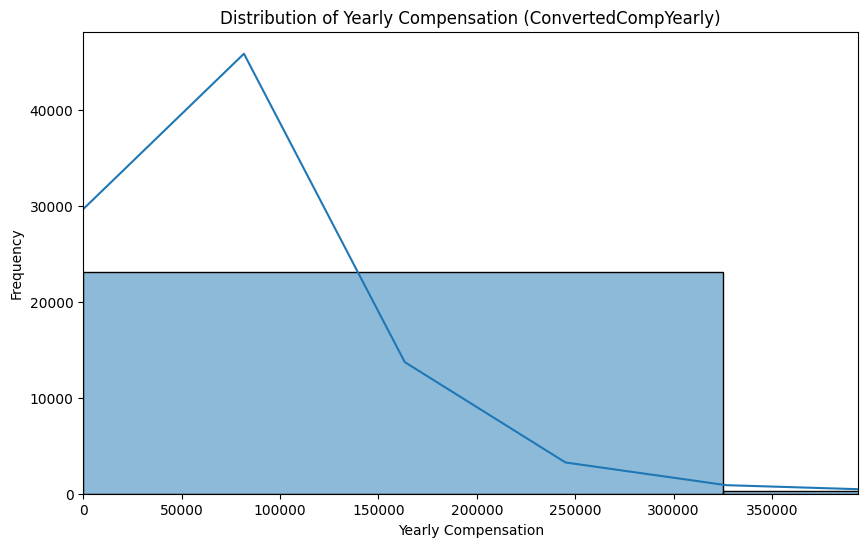

In [4]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Drop missing values in ConvertedCompYearly
comp_data = df['ConvertedCompYearly'].dropna()

# Basic statistics
print("Summary Statistics:")
print(comp_data.describe())

# Plot histogram with KDE
plt.figure(figsize=(10,6))
sns.histplot(comp_data, bins=50, kde=True)

plt.title("Distribution of Yearly Compensation (ConvertedCompYearly)")
plt.xlabel("Yearly Compensation")
plt.ylabel("Frequency")
plt.xlim(0, comp_data.quantile(0.99))  # Limit to 99th percentile to reduce extreme outlier impact

plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [5]:
## Write your code here
import pandas as pd

# Load the dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Filter for full-time employees
full_time_df = df[df['Employment'] == "Employed, full-time."]

# Drop missing compensation values
full_time_comp = full_time_df['ConvertedCompYearly'].dropna()

# Calculate median compensation
median_compensation = full_time_comp.median()

print("Median Yearly Compensation for Full-Time Employees:")
print(median_compensation)

Median Yearly Compensation for Full-Time Employees:
nan


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



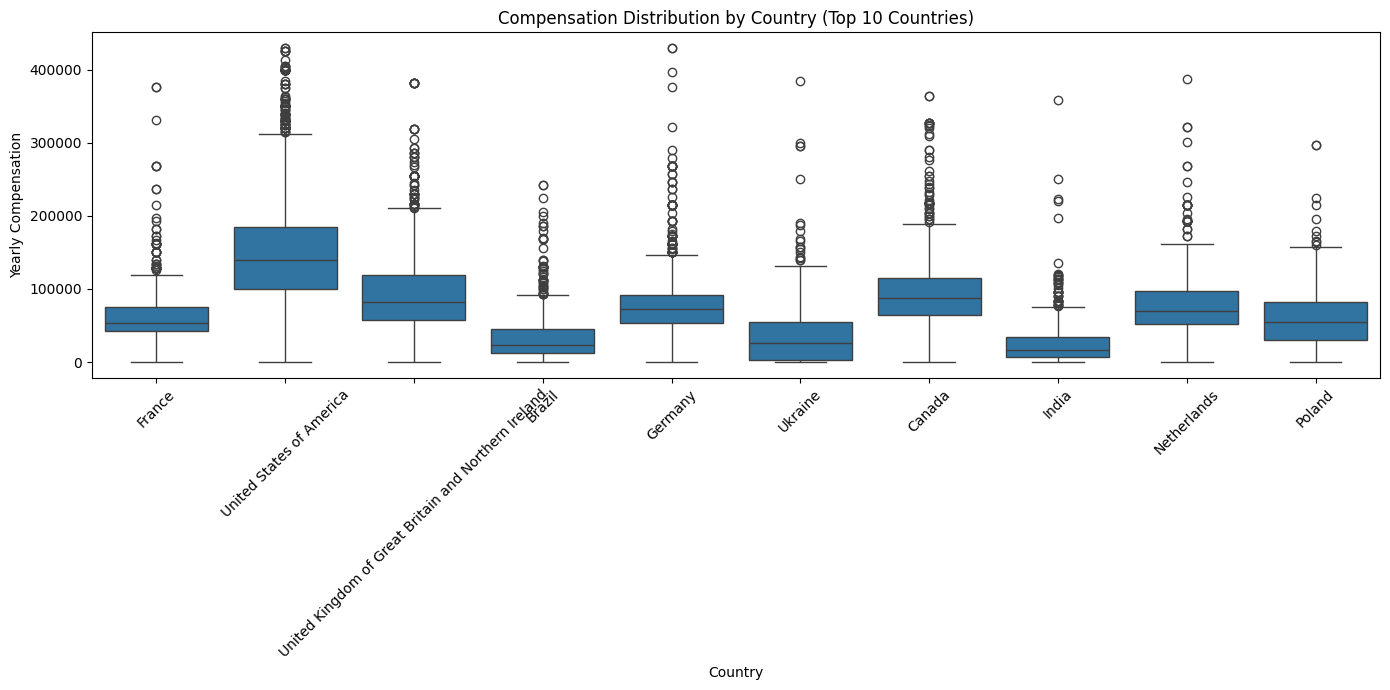

In [6]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Keep relevant columns and drop missing values
comp_country = df[['Country', 'ConvertedCompYearly']].dropna()

# Optional: Filter to top 10 countries by number of responses
top_countries = comp_country['Country'].value_counts().head(10).index
comp_country_top = comp_country[comp_country['Country'].isin(top_countries)]

# Limit extreme outliers using 99th percentile (optional but recommended)
upper_limit = comp_country_top['ConvertedCompYearly'].quantile(0.99)
comp_country_top = comp_country_top[
    comp_country_top['ConvertedCompYearly'] <= upper_limit
]

# Plot boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=comp_country_top,
    x='Country',
    y='ConvertedCompYearly'
)

plt.xticks(rotation=45)
plt.title("Compensation Distribution by Country (Top 10 Countries)")
plt.xlabel("Country")
plt.ylabel("Yearly Compensation")
plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [7]:
## Write your code here
import pandas as pd

# Load dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Drop missing compensation values
df_clean = df.dropna(subset=['ConvertedCompYearly'])

# Calculate Q1 and Q3
Q1 = df_clean['ConvertedCompYearly'].quantile(0.25)
Q3 = df_clean['ConvertedCompYearly'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create new dataframe without outliers
df_no_outliers = df_clean[
    (df_clean['ConvertedCompYearly'] >= lower_bound) &
    (df_clean['ConvertedCompYearly'] <= upper_bound)
]

print("Original dataset size:", df_clean.shape)
print("Dataset size after removing outliers:", df_no_outliers.shape)

Original dataset size: (23435, 114)
Dataset size after removing outliers: (22457, 114)


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


Correlation Matrix:
                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.153182        0.020156
WorkExp                         0.153182  1.000000       -0.028839
JobSatPoints_1                  0.020156 -0.028839        1.000000


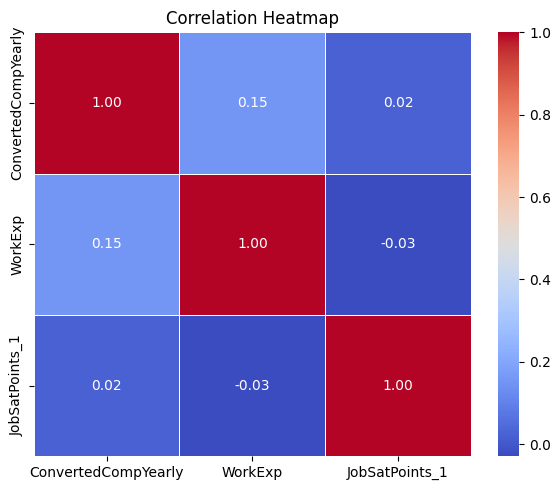

In [8]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Select relevant columns
corr_df = df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].dropna()

# Calculate correlation matrix (Pearson by default)
correlation_matrix = corr_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


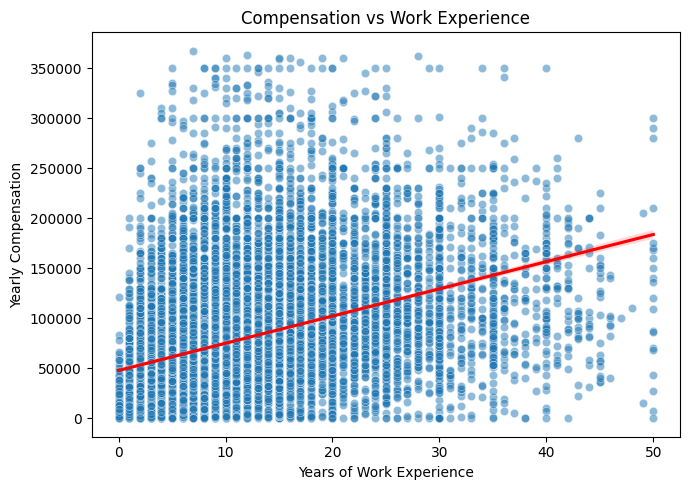

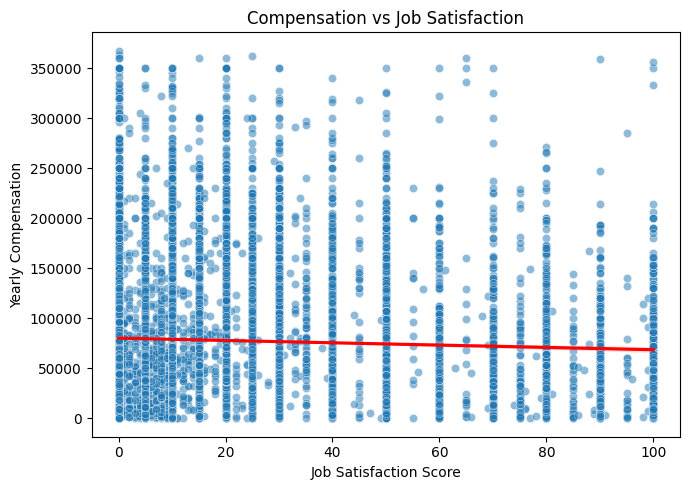

In [9]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Select relevant columns and drop missing values
scatter_df = df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].dropna()

# Optional: Reduce extreme outlier influence (recommended for salary data)
upper_limit = scatter_df['ConvertedCompYearly'].quantile(0.99)
scatter_df = scatter_df[scatter_df['ConvertedCompYearly'] <= upper_limit]

# ---- Scatter Plot 1: Compensation vs Work Experience ----
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=scatter_df,
    x='WorkExp',
    y='ConvertedCompYearly',
    alpha=0.5
)

sns.regplot(
    data=scatter_df,
    x='WorkExp',
    y='ConvertedCompYearly',
    scatter=False,
    color='red'
)

plt.title("Compensation vs Work Experience")
plt.xlabel("Years of Work Experience")
plt.ylabel("Yearly Compensation")
plt.tight_layout()
plt.show()


# ---- Scatter Plot 2: Compensation vs Job Satisfaction ----
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=scatter_df,
    x='JobSatPoints_1',
    y='ConvertedCompYearly',
    alpha=0.5
)

sns.regplot(
    data=scatter_df,
    x='JobSatPoints_1',
    y='ConvertedCompYearly',
    scatter=False,
    color='red'
)

plt.title("Compensation vs Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Yearly Compensation")
plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
